# Main Optotagging Analysis Notebook


Main notebook for analysis of cell-type distribution throughout the Allen Institute Visual Behavior Neuropixels Dataset. 

Uses imports from the visb_analysis package.

*Much of this project reuses code from the Allen Institute Visual Behavior Optotagging Tutorial notebook.*

### Loads data from `results/` folder

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

from visb_analysis.plots import (
    plot_units_per_session,
    plot_population_psth,
    plot_psth_heatmaps,
    plot_labeled_cells_by_region,
    plot_cre_density_by_region,
)

In [2]:
# Assumed you have saved results for all genotypes with run_all_sessions.py script
GENOTYPES = ["Vip", "Sst", "WT"]

configs = {}
for gt in GENOTYPES:
    cfg_path = Path("../configs") / f"{gt}.yaml"
    with cfg_path.open("r") as f:
        configs[gt] = yaml.safe_load(f)

data_by_genotype = {}
for gt, config in configs.items():
    results_dir = Path(config["results_dir"]) / gt
    all_psths_opto, all_psths_visual, all_unit_ids, all_units_meta = [], [], [], []
    time_bins_opto = time_bins_visual = None
    for npz_path in sorted(results_dir.glob("*.npz")):
        session_id = int(npz_path.stem)
        meta = pd.read_csv(results_dir / f"{session_id}_units.csv", index_col=0)
        all_units_meta.append(meta)
        if gt == 'WT':
            continue  # WT only needed for summary table, skip psth loading
        data = np.load(npz_path)
        all_psths_opto.append(data["psth_opto"])
        all_psths_visual.append(data["psth_visual"])
        all_unit_ids.append(data["unit_ids"])
        if time_bins_opto is None:
            time_bins_opto   = data["time_bins_opto"]
            time_bins_visual = data["time_bins_visual"]
    if not all_units_meta:
        raise FileNotFoundError(f"No result files found in {results_dir}")
    data_by_genotype[gt] = {
        "all_psths_opto":   all_psths_opto,
        "all_psths_visual": all_psths_visual,
        "all_units_meta":   all_units_meta,
        "time_bins_opto":   time_bins_opto,
        "time_bins_visual": time_bins_visual,
    }

derived = {}
for gt, d in data_by_genotype.items():
    meta_all = pd.concat(d["all_units_meta"])
    meta_all["optotagged"] = meta_all["optotagged"].fillna(False).astype(bool)
    opto_mask = meta_all["optotagged"].values
    entry = {
        "meta_all":       meta_all,
        "opto_mask":      opto_mask,
        "all_units_meta": d["all_units_meta"],
    }
    if gt != 'WT':
        psth_opto_avg   = np.concatenate(d["all_psths_opto"],   axis=0)
        psth_visual_avg = np.concatenate(d["all_psths_visual"], axis=0)
        entry.update({
            "psth_opto_tagged":   psth_opto_avg[opto_mask],
            "psth_opto_non":      psth_opto_avg[~opto_mask],
            "psth_visual_tagged": psth_visual_avg[opto_mask],
            "psth_visual_non":    psth_visual_avg[~opto_mask],
            "time_bins_opto":     d["time_bins_opto"],
            "time_bins_visual":   d["time_bins_visual"],
        })
    derived[gt] = entry

### Analyze & Visualize results

In [3]:
col_w = 14
print(f"{'':30}" + "".join(f"{gt:>{col_w}}" for gt in GENOTYPES))
print("-" * (30 + col_w * len(GENOTYPES)))

stats = {}
for gt, d in derived.items():
    om    = d["opto_mask"]
    metas = d["all_units_meta"]
    sess_pos = [m["optotagged"].fillna(False).astype(bool).sum() for m in metas]
    stats[gt] = {
        "sessions":       len(metas),
        "total":          len(om),
        "labeled":        int(om.sum()),
        "unlabeled":      int((~om).sum()),
        "pct":            100 * om.mean(),
        "mean_per_sess":  np.mean(sess_pos),
        "std_per_sess":   np.std(sess_pos),
    }

def _row(label, fn):
    print(f"{label:30}" + "".join(f"{fn(stats[gt]):>{col_w}}" for gt in GENOTYPES))

_row("Sessions",           lambda s: str(s["sessions"]))
_row("Total units",        lambda s: str(s["total"]))
_row("Labeled (Cre+)",     lambda s: f"{s['labeled']} ({s['pct']:.1f}%)")
_row("Unlabeled",          lambda s: str(s["unlabeled"]))
_row("Mean Cre+/session",  lambda s: f"{s['mean_per_sess']:.1f}")
_row("Std Cre+/session",   lambda s: f"{s['std_per_sess']:.1f}")

                                         Vip           Sst            WT
------------------------------------------------------------------------
Sessions                                  22            43            38
Total units                            31204         56771         52076
Labeled (Cre+)                    105 (0.3%)   2538 (4.5%)     10 (0.0%)
Unlabeled                              31099         54233         52066
Mean Cre+/session                        4.8          59.0           0.3
Std Cre+/session                         3.3          27.1           0.5


## Opto Pulse PSTH — Population average

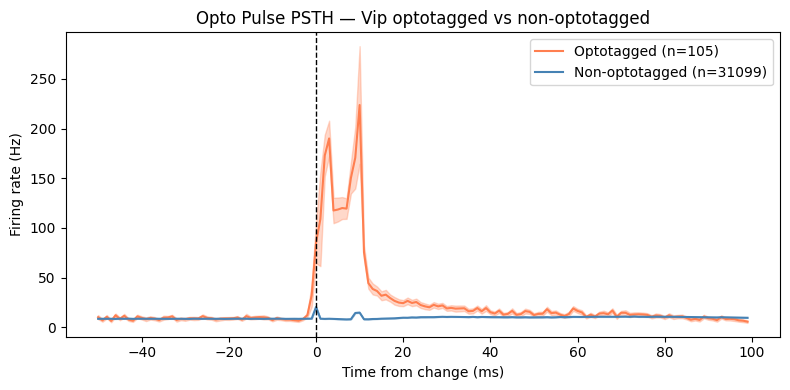

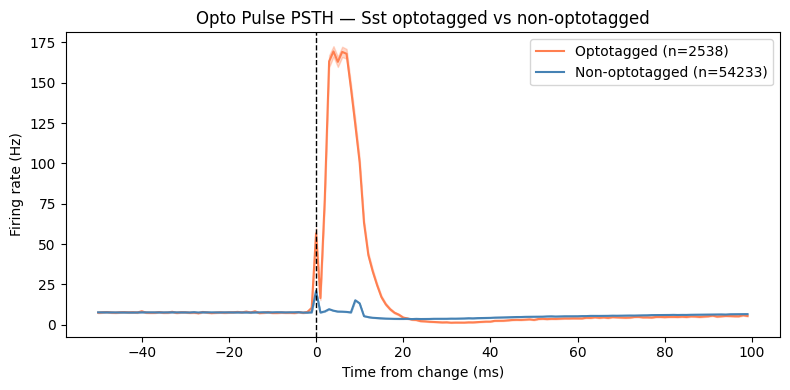

In [12]:
for gt, d in derived.items():
    if gt == 'WT':
        continue
    fig = plot_population_psth(
        d["psth_opto_tagged"], d["psth_opto_non"], d["time_bins_opto"],
        title=f'Opto Pulse PSTH — {gt} optotagged vs non-optotagged',
    )

## Opto Pulse PSTH — Unit heatmap (sorted by response magnitude)

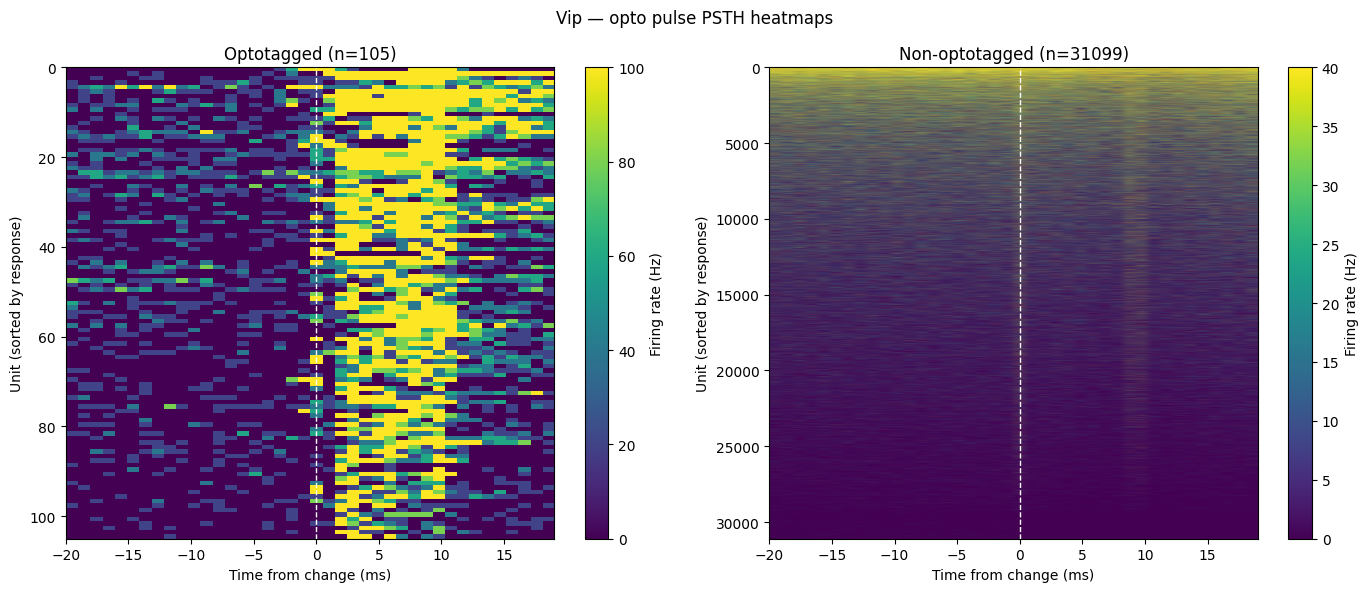

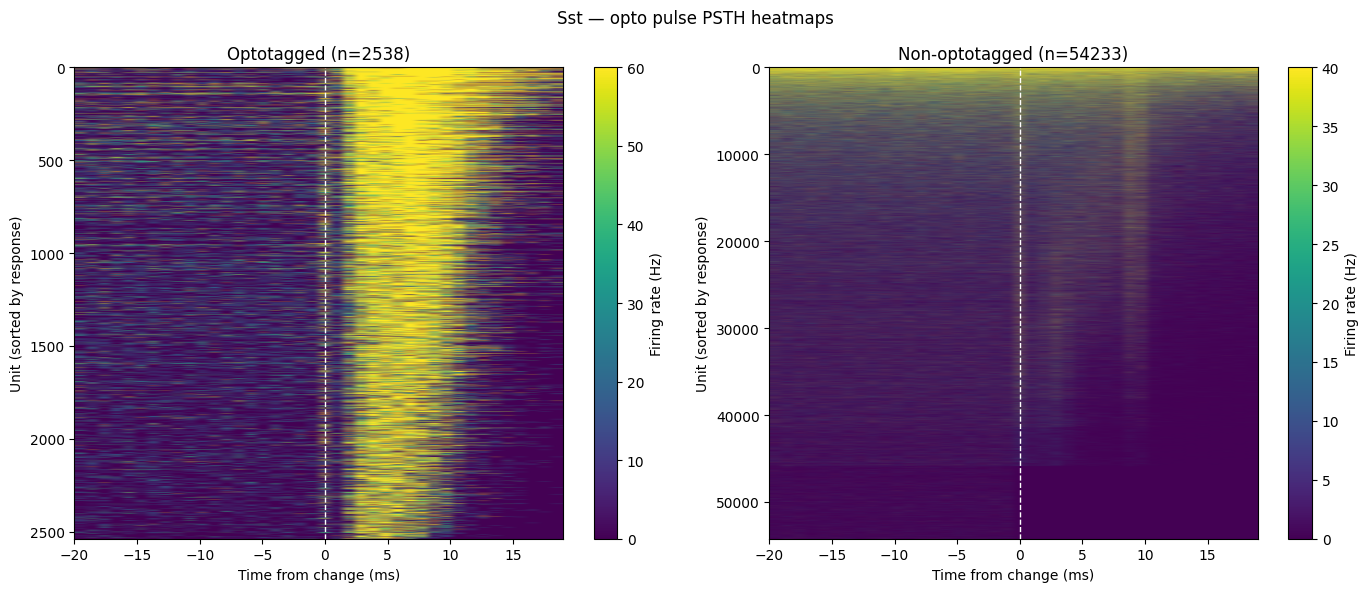

In [5]:
for gt, d in derived.items():
    if gt == 'WT':
        continue
    fig = plot_psth_heatmaps(
        d["psth_opto_tagged"], d["psth_opto_non"], d["time_bins_opto"],
        suptitle=f'{gt} — opto pulse PSTH heatmaps',
        time_range=(-0.02, 0.02),
    )

## Image Change PSTH — Population average

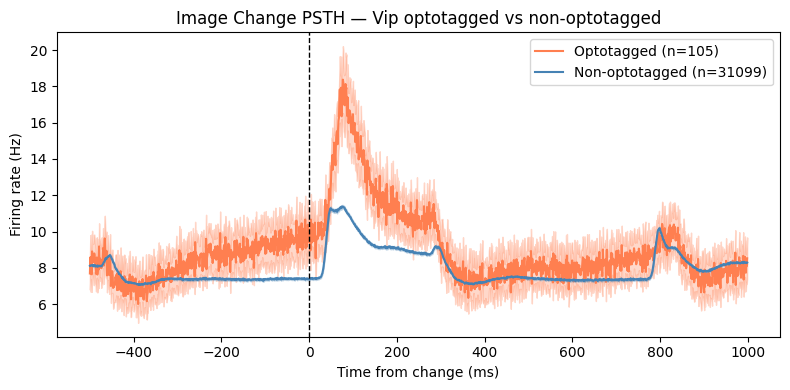

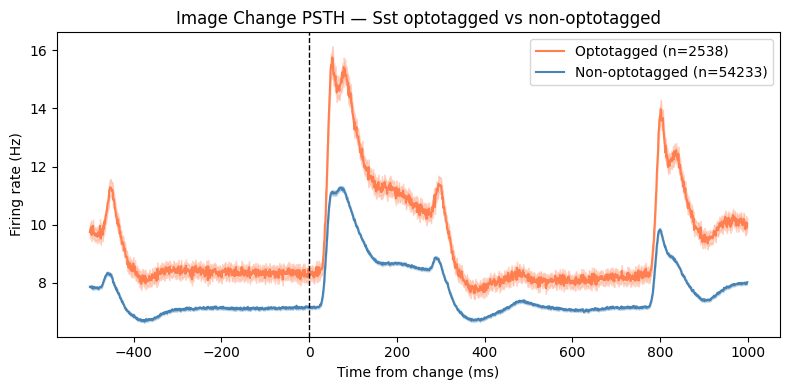

In [6]:
for gt, d in derived.items():
    if gt == 'WT':
        continue
    fig = plot_population_psth(
        d["psth_visual_tagged"], d["psth_visual_non"], d["time_bins_visual"],
        title=f'Image Change PSTH — {gt} optotagged vs non-optotagged',
    )

## Image Change PSTH — Unit heatmap (sorted by response magnitude)

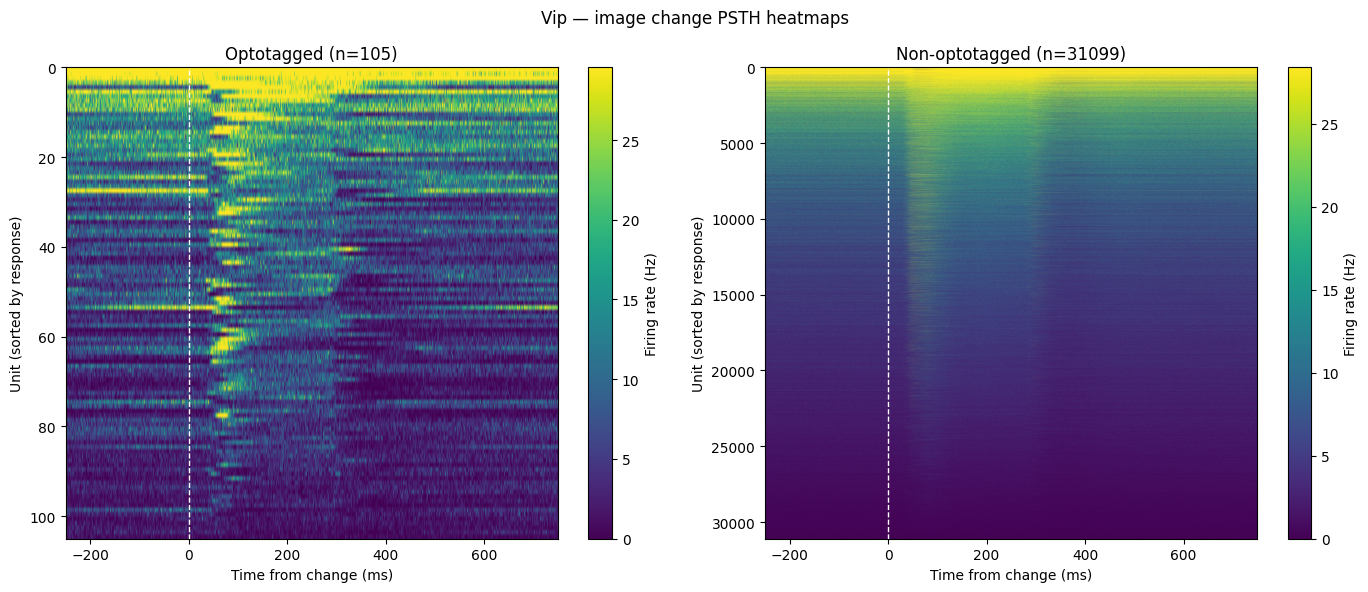

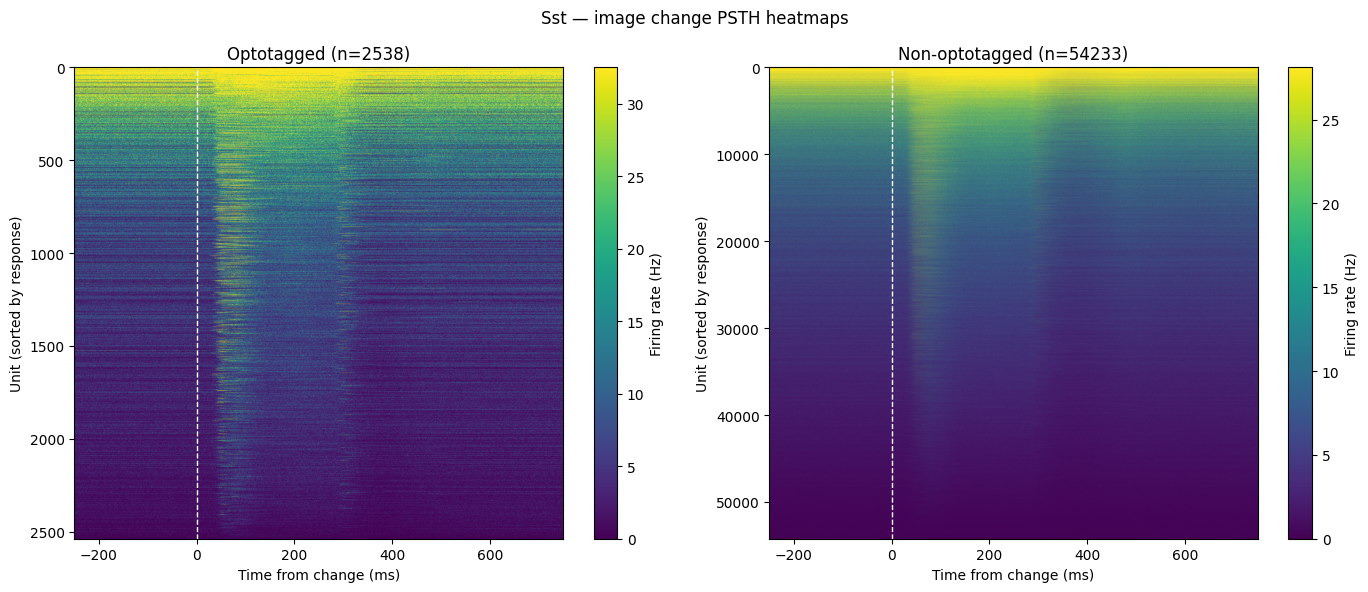

In [7]:
for gt, d in derived.items():
    if gt == 'WT':
        continue
    fig = plot_psth_heatmaps(
        d["psth_visual_tagged"], d["psth_visual_non"], d["time_bins_visual"],
        suptitle=f'{gt} — image change PSTH heatmaps',
        time_range=(-0.25, 0.75),
    )

### Region Distribution Analysis

Loads saved results for **all genotypes** (Vip + Sst) to characterize the labeled neurons across the dataset.

-> Analysis of how many Vip+ / Sst+ neurons we have in each region (absolute counts)

-> Within each genotype's own sessions, how dense are the labeled neurons per region?

In [8]:
genotype_meta = {gt: d["meta_all"] for gt, d in derived.items() if gt != 'WT'}

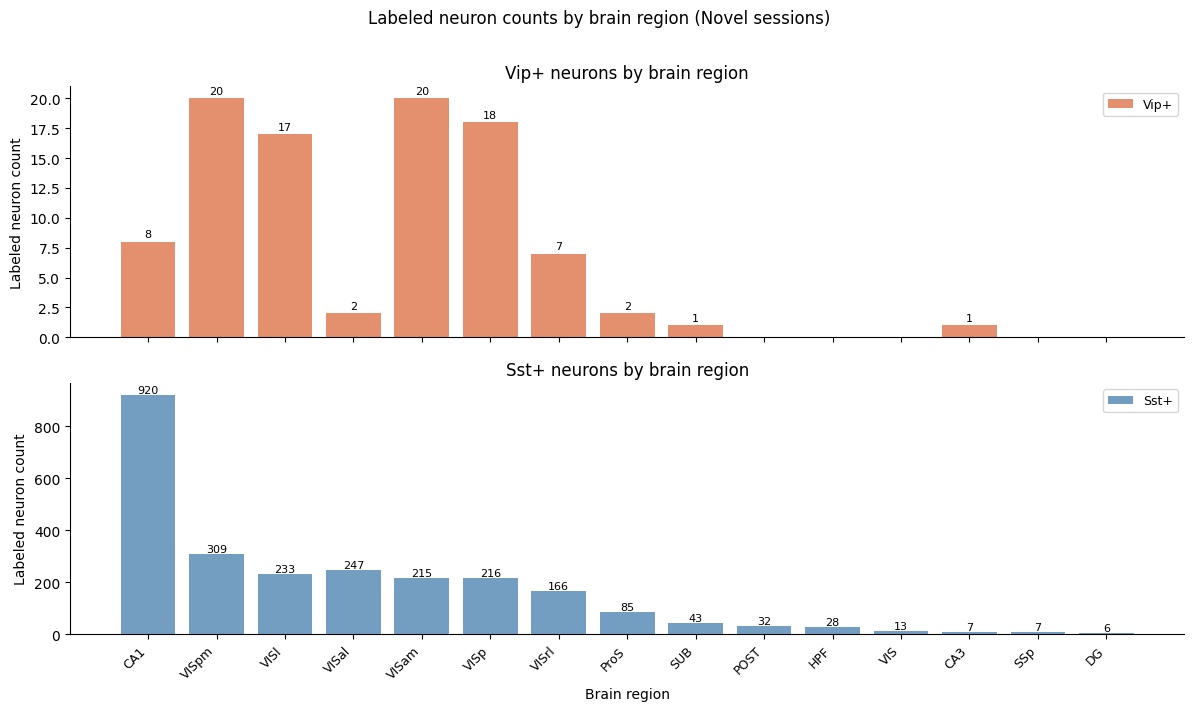

In [9]:
# Absolute labeled neuron counts per region
fig = plot_labeled_cells_by_region(genotype_meta, min_labeled=5)

##### Labeled neuron density per region, within each genotype's own sessions

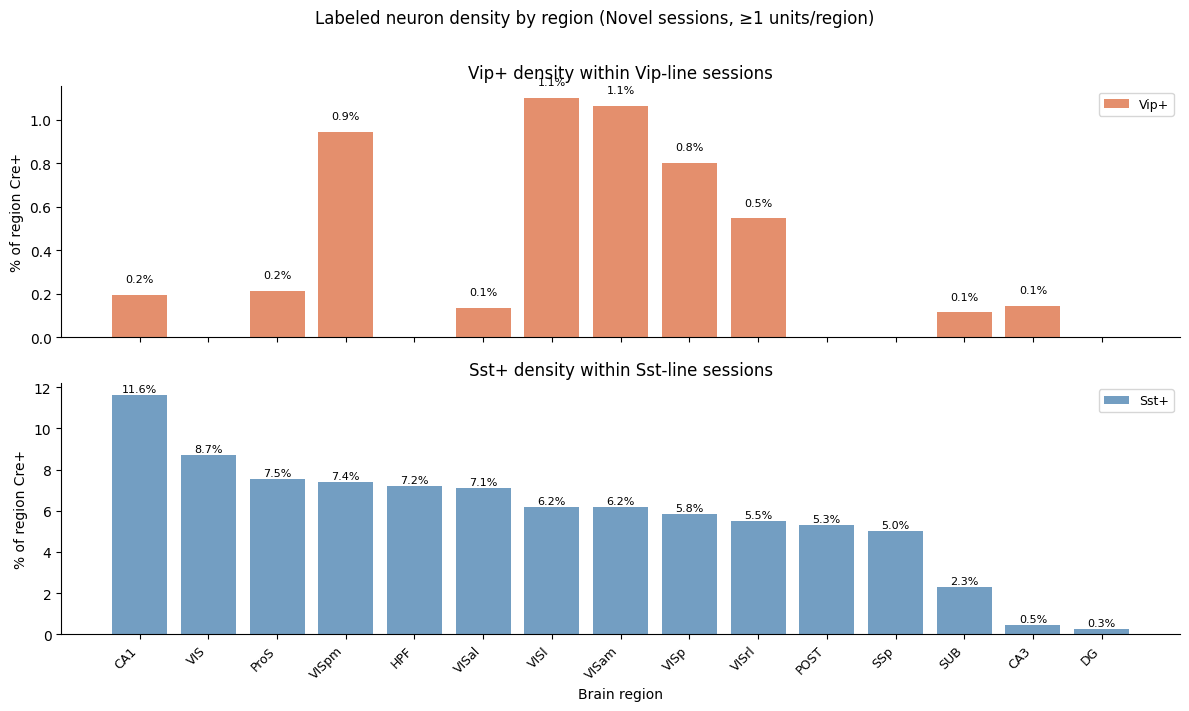

In [10]:
fig = plot_cre_density_by_region(genotype_meta, min_units=1, min_labeled=5)